# Financial Volatility & Correlation Analysis

**An end-to-end risk study of 25 liquid assets** — US large-cap stocks, equity ETFs (broad market and
sectors) and commodity ETFs — built on the shared `finrisk` analytics package, the same engine
that powers the Streamlit dashboard and the command-line pipeline in this repository.

This notebook covers:

1. Data acquisition and coverage
2. Risk & return profile
3. Benchmark-relative statistics (beta, alpha, tracking error, information ratio, up/down capture)
4. Correlation structure
5. Calendar-year performance
6. Drawdown episodes and tail risk
7. Mean-variance portfolio optimization (Monte Carlo cloud and efficient frontier)
8. Walk-forward backtest (out-of-sample) and stress scenarios
9. Risk decomposition and risk models (VaR backtest, GARCH forecasts)
10. Executive summary and artifact exports

**Data.** Live adjusted prices from Yahoo Finance (via `yfinance`), with `data/price_history.csv` as an
offline fallback. The panel is aligned to the common window of the universe, so every cross-asset
statistic uses the same sample.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

import finrisk as an
from finrisk import presentation as pres

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

RISK_FREE = 0.04  # annual risk-free rate used by Sharpe / Sortino / alpha
MC_PORTFOLIOS = 10_000

## 1. Data acquisition

`finrisk.fetch_prices` downloads adjusted closes for the full universe and falls back to the local
snapshot when the network is unavailable. The analytics bundle produced here is reused by every
section below: returns, risk metrics, correlations, drawdowns, Monte Carlo portfolios and the
optimized weights.

In [2]:
TICKERS = an.default_tickers()

try:
    prices = an.fetch_prices(TICKERS)
    an.save_prices(prices)  # refresh the offline snapshot with the latest data
    source = "live"
except Exception as exc:  # noqa: BLE001 - any failure falls back to the local snapshot
    prices = an.load_prices(TICKERS)
    source = "snapshot"
    print(f"Live fetch unavailable ({exc}); using the local snapshot.")

bundle = an.compute_all(
    tickers=TICKERS,
    prices=prices,
    rf=RISK_FREE,
    mc_portfolios=MC_PORTFOLIOS,
    source=source,
)

print(f"Assets: {len(bundle.metrics)} | trading days: {len(bundle.returns):,}")
print(f"Window: {bundle.prices.index[0]:%Y-%m-%d} to {bundle.prices.index[-1]:%Y-%m-%d} | source: {source}")

Assets: 113 | trading days: 3,613
Window: 2012-05-18 to 2026-10-02 | source: live


## 2. Data coverage

Every retained asset has an observation on every date in the sample (the common window of the
selected universe), so cross-asset statistics are computed on one aligned panel.

In [3]:
coverage = pd.DataFrame(
    {
        "Class": [an.asset_class(ticker) for ticker in bundle.prices.columns],
        "Name": [an.asset_name(ticker) for ticker in bundle.prices.columns],
        "First day": bundle.prices.apply(lambda column: column.first_valid_index().date()),
        "Last day": bundle.prices.apply(lambda column: column.last_valid_index().date()),
        "Observations": bundle.prices.count(),
    },
    index=bundle.prices.columns,
)
display(coverage.head(8))
missing = int(bundle.prices.isna().sum().sum())
print(f"{len(coverage)} assets in total | missing values: {missing}")

,Class,Name,First day,Last day,Observations
Ticker,,,,,
AAPL,STOCK,Apple Inc.,2012-05-18,2026-10-02,3614
MSFT,STOCK,Microsoft Corp.,2012-05-18,2026-10-02,3614
GOOGL,STOCK,Alphabet Inc.,2012-05-18,2026-10-02,3614
AMZN,STOCK,Amazon.com Inc.,2012-05-18,2026-10-02,3614
NVDA,STOCK,NVIDIA Corp.,2012-05-18,2026-10-02,3614
META,STOCK,Meta Platforms Inc.,2012-05-18,2026-10-02,3614
TSLA,STOCK,Tesla Inc.,2012-05-18,2026-10-02,3614
JPM,STOCK,JPMorgan Chase & Co.,2012-05-18,2026-10-02,3614


113 assets in total | missing values: 0


## 3. Risk & return profile

Core per-asset metrics: geometric CAGR, annualized volatility, Sharpe / Sortino ratios, maximum
drawdown and historical-simulation VaR/CVaR. The second table adds benchmark-relative statistics
against the selected benchmark.

In [4]:
RISK_COLUMNS = [
    "Asset_Class",
    "Annualized_Return",
    "Annualized_Volatility",
    "Sharpe_Ratio",
    "Sortino_Ratio",
    "Max_Drawdown",
    "Calmar_Ratio",
    "VaR_95",
    "CVaR_95",
]
display(pres.metric_style(bundle.metrics[RISK_COLUMNS].sort_values("Sharpe_Ratio", ascending=False)))

,Asset_Class,Annualized_Return,Annualized_Volatility,Sharpe_Ratio,Sortino_Ratio,Max_Drawdown,Calmar_Ratio,VaR_95,CVaR_95
Ticker,,,,,,,,,
NVDA,STOCK,60.03%,44.89%,1.182,1.823,-66.34%,0.905,4.09%,6.09%
SMH,ETF,31.02%,30.04%,0.917,1.326,-45.30%,0.685,2.96%,4.39%
TSLA,STOCK,44.79%,57.00%,0.863,1.314,-73.63%,0.608,5.12%,7.75%
COST,STOCK,20.94%,20.50%,0.836,1.208,-31.40%,0.667,1.84%,2.93%
XLK,ETF,22.10%,22.41%,0.825,1.183,-33.56%,0.659,2.21%,3.29%
QQQ,ETF,20.18%,20.65%,0.800,1.134,-35.12%,0.575,2.06%,3.09%
MSFT,STOCK,24.23%,26.61%,0.798,1.183,-37.15%,0.652,2.51%,3.73%
GOOGL,STOCK,24.48%,27.85%,0.782,1.163,-44.32%,0.552,2.53%,3.91%
AAPL,STOCK,23.67%,28.25%,0.752,1.092,-43.80%,0.541,2.66%,4.07%


In [5]:
if bundle.benchmark:
    RELATIVE_COLUMNS = [
        "Beta",
        "Alpha",
        "Tracking_Error",
        "Information_Ratio",
        "Up_Capture",
        "Down_Capture",
    ]
    relative = bundle.metrics[RELATIVE_COLUMNS].sort_values("Information_Ratio", ascending=False)
    display(pres.metric_style(relative))
else:
    print("No benchmark available in this selection; benchmark-relative statistics skipped.")

,Beta,Alpha,Tracking_Error,Information_Ratio,Up_Capture,Down_Capture
Ticker,,,,,,
NVDA,1.716,33.22%,36.64%,1.132,2.541,1.110
SMH,1.446,10.84%,19.48%,0.821,1.581,1.057
TSLA,1.601,30.67%,51.38%,0.732,2.359,0.819
XLK,1.235,4.22%,9.80%,0.708,1.246,1.012
QQQ,1.156,3.17%,8.01%,0.620,1.185,1.025
MSFT,1.165,7.77%,18.45%,0.525,1.285,0.893
GOOGL,1.145,8.54%,20.47%,0.499,1.353,0.981
MS,1.365,5.85%,21.57%,0.467,1.540,1.419
AAPL,1.164,7.80%,20.77%,0.467,1.380,1.062


## 4. Correlation structure

Pairwise correlations of daily returns. Lower average correlation means stronger diversification
potential; the extremes highlight natural hedges and near-duplicates.

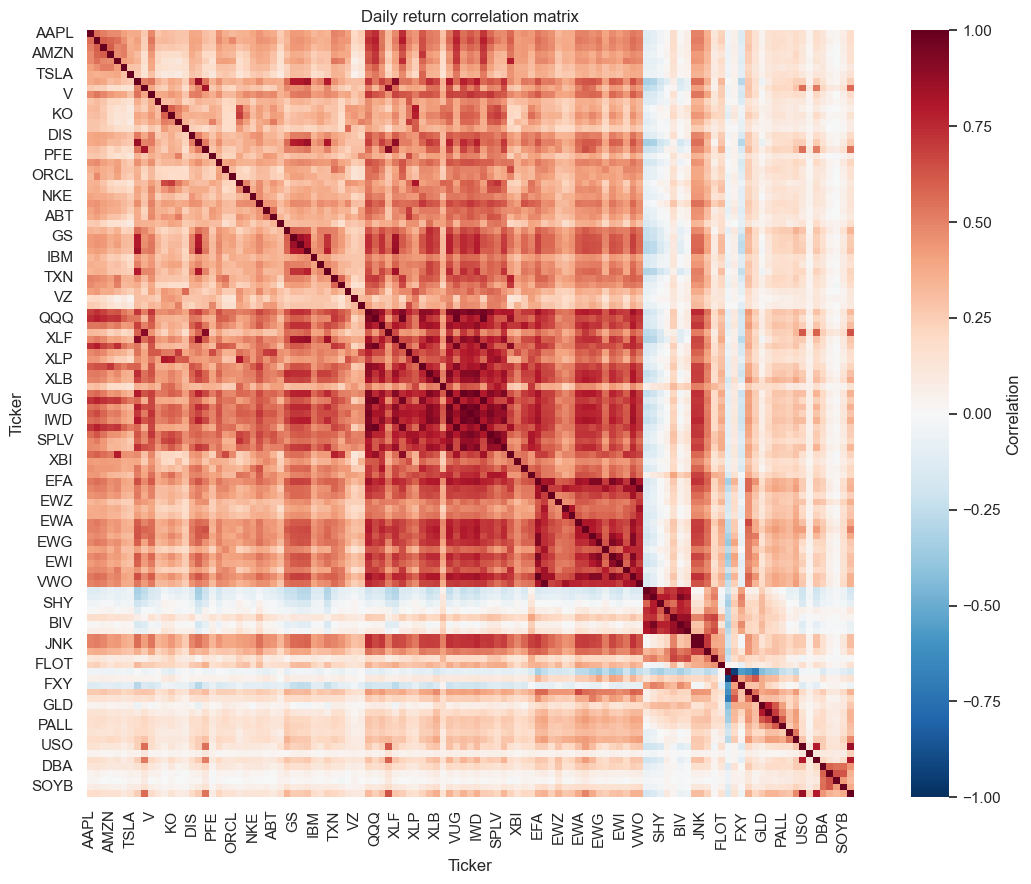

Strongest pair: EFA / VEA (0.99)
Weakest pair:   UUP / FXE (-0.94)
Average pairwise correlation: 0.33


In [6]:
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    bundle.correlation,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    ax=ax,
    cbar_kws={"label": "Correlation"},
)
ax.set_title("Daily return correlation matrix")
plt.tight_layout()
plt.show()

(hi_a, hi_b, hi_value), (lo_a, lo_b, lo_value) = an.correlation_extremes(bundle.correlation)
print(f"Strongest pair: {hi_a} / {hi_b} ({hi_value:.2f})")
print(f"Weakest pair:   {lo_a} / {lo_b} ({lo_value:.2f})")
print(f"Average pairwise correlation: {an.average_correlation(bundle.correlation):.2f}")

## 5. Calendar-year performance

Total returns compounded from daily data. The first and last years of the sample may be partial
depending on the selected window.

Ticker,AAPL,MSFT,GOOGL,AMZN,NVDA,META,TSLA,JPM,XOM,V,UNH,PG,KO,JNJ,WMT,DIS,BAC,CVX,PFE,CSCO,...,FLOT,UUP,FXE,FXY,FXA,FXB,GLD,SLV,PPLT,PALL,CPER,DBB,USO,UNG,UGA,DBA,CORN,WEAT,SOYB,DBC
Year,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2019,89.0,57.6,28.2,23.0,76.9,56.6,25.7,47.3,7.2,43.3,20.0,39.7,20.6,16.2,30.2,33.5,46.2,15.3,-6.9,13.8,...,4.0,4.1,-2.9,0.4,0.1,3.9,17.9,14.9,20.9,53.9,6.7,-1.2,32.6,-31.8,41.2,-0.7,-7.8,-1.3,-2.2,11.8
2020,82.3,42.5,30.9,76.3,122.3,33.1,743.4,-5.5,-36.2,17.1,21.3,14.2,2.5,10.8,23.3,25.3,-11.6,-26.0,3.1,-3.5,...,0.9,-6.7,7.9,4.6,9.5,2.9,24.8,47.3,10.8,25.3,23.9,15.5,-67.8,-45.4,-24.9,-2.5,5.3,5.8,23.0,-7.8
2021,34.6,52.5,65.3,2.4,125.5,23.1,49.8,27.7,57.6,-0.3,45.2,20.5,11.4,11.4,2.0,-14.5,49.6,46.2,66.7,45.8,...,0.4,5.7,-7.8,-10.9,-6.2,-1.5,-4.1,-12.5,-10.8,-23.3,25.2,29.0,64.7,35.8,68.5,22.4,38.3,19.4,16.8,41.4
2022,-26.4,-28.0,-39.1,-49.6,-50.3,-64.2,-65.0,-12.6,87.4,-3.4,6.9,-5.0,10.6,6.0,-0.5,-43.9,-23.8,58.5,-10.4,-22.5,...,1.3,9.5,-6.6,-12.8,-6.5,-10.5,-0.8,2.4,10.4,-6.3,-15.1,-11.8,29.0,12.9,46.3,2.5,25.0,8.0,25.3,19.3
2023,49.0,58.2,58.3,80.9,239.0,194.1,101.7,30.6,-6.3,26.3,0.8,-0.9,-4.4,-8.6,12.9,4.3,4.8,-13.6,-41.3,9.3,...,6.4,3.6,4.9,-7.4,1.2,8.4,12.7,-1.1,-8.2,-38.8,4.5,1.1,-4.9,-64.0,1.3,7.6,-19.9,-25.2,-5.2,-6.2
2024,30.7,12.9,36.0,44.4,171.2,66.0,62.5,44.3,11.3,22.3,-2.4,17.3,8.9,-4.8,74.0,24.4,33.9,1.3,-2.2,21.0,...,6.5,13.5,-4.2,-10.9,-7.7,1.4,26.7,20.9,-8.9,-17.4,4.2,7.9,13.4,-17.1,3.8,33.4,-13.0,-19.3,-20.5,2.2
2025,9.1,15.6,66.0,5.2,38.9,13.1,11.4,37.3,16.0,11.8,-33.1,-12.3,15.6,47.5,24.5,3.3,28.0,10.1,0.6,33.5,...,4.9,-5.0,14.5,0.1,9.1,10.4,63.7,144.7,124.5,74.1,39.0,25.0,-8.5,-27.1,-2.0,-0.6,-5.5,-17.1,1.8,8.1
2026,23.1,7.7,10.0,9.0,25.7,10.6,-17.6,4.6,39.0,3.5,14.9,3.4,24.9,25.7,-5.8,-9.5,-0.7,39.4,17.4,48.4,...,3.2,6.9,-3.6,-1.0,5.2,-0.2,-4.1,-15.0,-17.2,-26.9,13.0,8.5,113.1,-14.6,141.8,10.5,6.3,23.9,24.5,45.5


Total return per calendar year (%), last 8 years; first and last years may be partial.


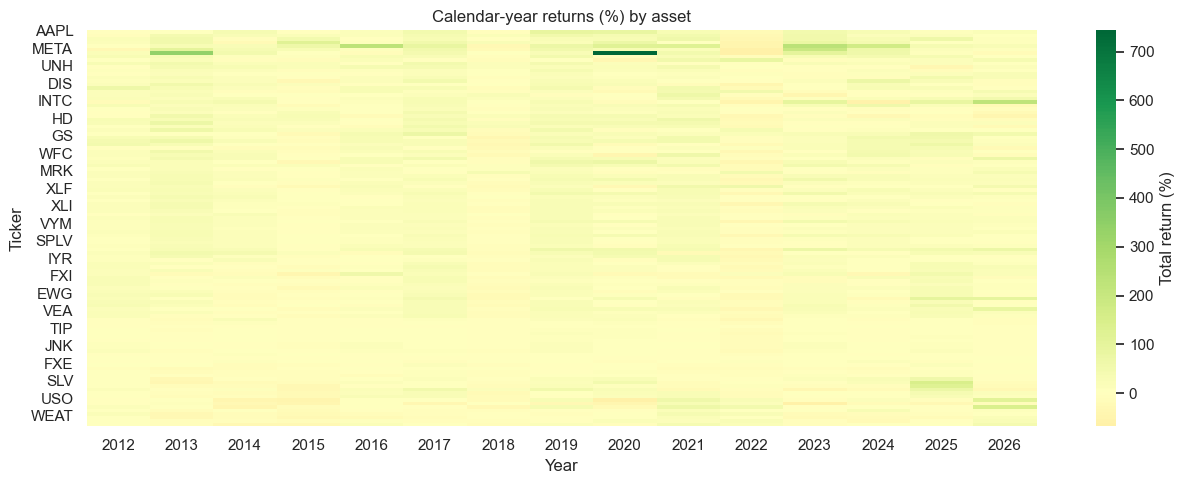

In [7]:
yearly = an.calendar_year_returns(bundle.returns)
display((yearly * 100).round(1).iloc[-8:])
print("Total return per calendar year (%), last 8 years; first and last years may be partial.")

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(yearly.T * 100, cmap="RdYlGn", center=0, ax=ax, cbar_kws={"label": "Total return (%)"})
ax.set_title("Calendar-year returns (%) by asset")
ax.set_xlabel("Year")
plt.tight_layout()
plt.show()

## 6. Drawdown & tail risk

Underwater plot for the benchmark and the optimized portfolios, followed by the largest drawdown
episodes for the benchmark with depth and recovery timing.

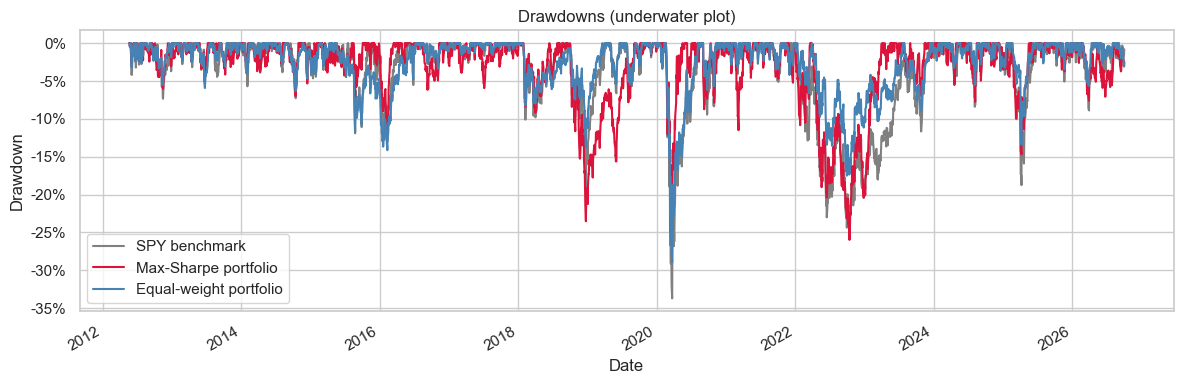

,Peak,Trough,Recovery,Depth,Trough_Days,Recovery_Days
0,2020-02-19,2020-03-23,2020-08-10,-33.7%,23,97
1,2022-01-03,2022-10-12,2023-12-13,-24.5%,195,294
2,2018-09-20,2018-12-24,2019-04-12,-19.3%,65,75
3,2025-02-19,2025-04-08,2025-06-26,-18.8%,34,54
4,2015-07-20,2016-02-11,2016-04-18,-13.0%,143,45


In [8]:
tracked = {
    f"{bundle.benchmark} benchmark": bundle.returns[bundle.benchmark],
    "Max-Sharpe portfolio": an.portfolio_returns(bundle.returns, bundle.max_sharpe),
    "Equal-weight portfolio": an.portfolio_returns(bundle.returns, bundle.equal_weight),
}
drawdowns = an.drawdown_series(pd.DataFrame(tracked))
ax = drawdowns.plot(figsize=(12, 4), color=["gray", "crimson", "steelblue"])
ax.set_title("Drawdowns (underwater plot)")
ax.set_ylabel("Drawdown")
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
plt.tight_layout()
plt.show()

episodes = an.drawdown_episodes(bundle.returns[bundle.benchmark], top=5)
for column in ("Peak", "Trough", "Recovery"):
    episodes[column] = episodes[column].dt.strftime("%Y-%m-%d").fillna("—")
episodes["Depth"] = episodes["Depth"].map(lambda value: f"{value:.1%}")
episodes["Recovery_Days"] = episodes["Recovery_Days"].map(lambda value: "—" if pd.isna(value) else f"{value:.0f}")
display(episodes)

## 7. Portfolio optimization

Long-only mean-variance optimization (SLSQP) on the in-sample covariance: the maximum-Sharpe and
minimum-variance portfolios against equal weight, plus a Monte Carlo cloud around the efficient
frontier.

Returns are in-sample and exclude transaction costs — treat them as a relative comparison, not a
tradable backtest.

In [9]:
portfolios = {
    "Max Sharpe": bundle.max_sharpe,
    "Min Variance": bundle.min_variance,
    "Equal Weight": bundle.equal_weight,
}
comparison = pd.DataFrame(
    {name: an.portfolio_stats(bundle.returns, weights, rf=RISK_FREE)[0] for name, weights in portfolios.items()}
).T
display(pres.metric_style(comparison))

weights_table = pd.DataFrame({name: weights[weights > 0.005] for name, weights in portfolios.items()})
display(weights_table.style.format("{:.1%}", na_rep="—"))

,Annualized_Return,Annualized_Volatility,Sharpe_Ratio,Sortino_Ratio,Max_Drawdown,Calmar_Ratio,VaR_95,CVaR_95,Total_Return
Max Sharpe,30.31%,17.11%,1.400,2.070,-25.99%,1.166,1.58%,2.43%,4350.03%
Min Variance,1.21%,0.65%,-4.294,-5.205,-2.24%,0.541,0.04%,0.07%,18.81%
Equal Weight,12.11%,12.75%,0.647,0.897,-28.95%,0.418,1.15%,1.88%,414.68%


,Max Sharpe,Min Variance,Equal Weight
Ticker,,,
AAPL,—,—,0.9%
ABT,—,—,0.9%
AMZN,—,—,0.9%
BAC,—,—,0.9%
BIV,—,—,0.9%
BND,—,—,0.9%
C,—,—,0.9%
CAT,—,—,0.9%
CORN,—,—,0.9%


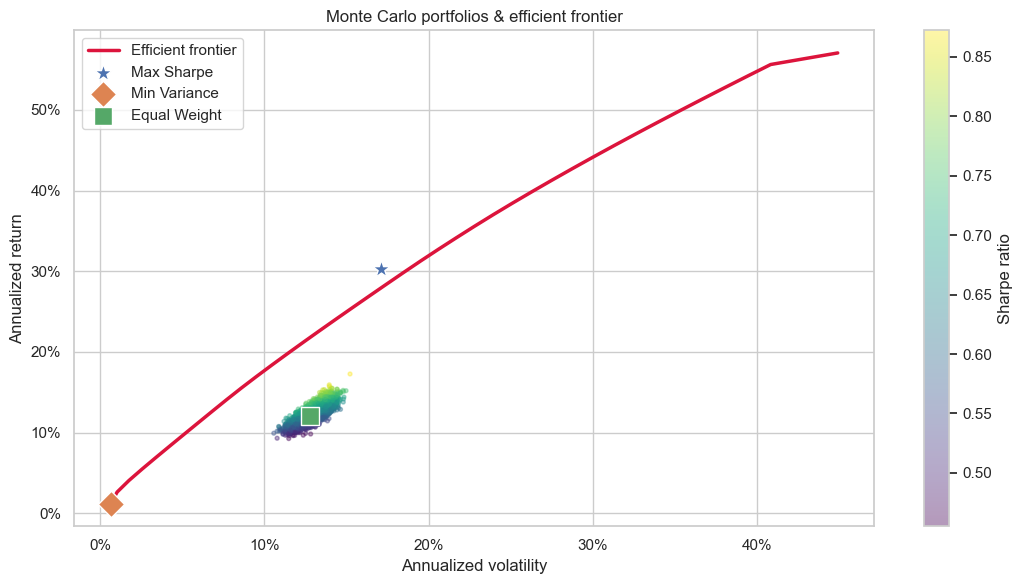

In [10]:
fig, ax = plt.subplots(figsize=(11, 6))
cloud = bundle.monte_carlo.sample(4000, random_state=0)
scatter = ax.scatter(
    cloud["Annualized_Volatility"],
    cloud["Annualized_Return"],
    c=cloud["Sharpe_Ratio"],
    cmap="viridis",
    s=8,
    alpha=0.4,
)
ax.plot(
    bundle.frontier["Annualized_Volatility"],
    bundle.frontier["Annualized_Return"],
    color="crimson",
    linewidth=2.5,
    label="Efficient frontier",
)
markers = [
    ("Max Sharpe", bundle.max_sharpe, "*"),
    ("Min Variance", bundle.min_variance, "D"),
    ("Equal Weight", bundle.equal_weight, "s"),
]
for name, weights, marker in markers:
    stats, _ = an.portfolio_stats(bundle.returns, weights, rf=RISK_FREE)
    ax.scatter(
        [stats["Annualized_Volatility"]],
        [stats["Annualized_Return"]],
        marker=marker,
        s=180,
        edgecolors="white",
        label=name,
        zorder=5,
    )
ax.set(
    xlabel="Annualized volatility",
    ylabel="Annualized return",
    title="Monte Carlo portfolios & efficient frontier",
)
ax.xaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
plt.colorbar(scatter, ax=ax, label="Sharpe ratio")
ax.legend()
plt.tight_layout()
plt.show()

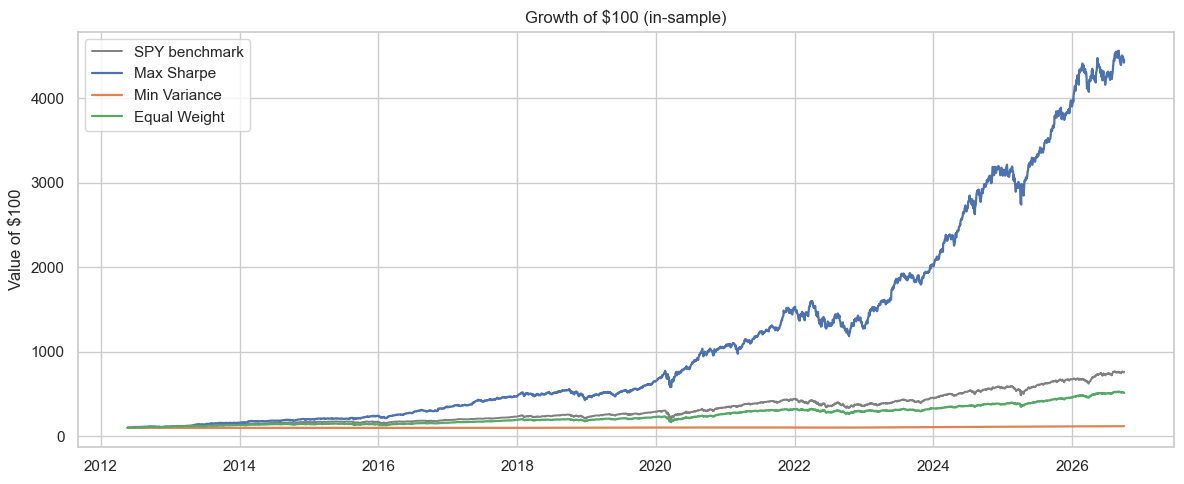

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
benchmark_growth = 100 * (1 + bundle.returns[bundle.benchmark]).cumprod()
ax.plot(benchmark_growth, color="gray", linewidth=1.4, label=f"{bundle.benchmark} benchmark")
for name, weights in portfolios.items():
    growth = 100 * (1 + an.portfolio_returns(bundle.returns, weights)).cumprod()
    ax.plot(growth, linewidth=1.6, label=name)
ax.set(ylabel="Value of $100", title="Growth of $100 (in-sample)")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Walk-forward backtest

Weights are re-estimated each month on the trailing three years and held out-of-sample; 10 bp one-way costs are charged on turnover. This is the honest test of the optimization: the fitted portfolios have to compete with equal weight and the benchmark on data they never saw.

In [12]:
extended = an.compute_extended(bundle)

backtest_table = extended.backtest.stats[
    [
        "Annualized_Return",
        "Annualized_Volatility",
        "Sharpe_Ratio",
        "Max_Drawdown",
        "Avg_Turnover",
        "Annual_Cost",
        "Total_Return",
    ]
]
display(pres.metric_style(backtest_table))

,Annualized_Return,Annualized_Volatility,Sharpe_Ratio,Max_Drawdown,Avg_Turnover,Annual_Cost,Total_Return
Max Sharpe,10.51%,11.54%,0.577,-29.12%,17.16%,0.21%,209.87%
Min Variance,1.66%,1.30%,-1.797,-3.44%,2.37%,0.03%,20.50%
Equal Weight,11.62%,13.52%,0.585,-28.95%,0.73%,0.01%,247.15%
SPY,13.99%,17.69%,0.603,-33.72%,—,—,340.43%


## 9. Stress scenarios

Total return and maximum drawdown of each portfolio inside historical crisis windows — the scenario view a risk committee asks for.

In [13]:
display((extended.scenario_returns * 100).round(1))
display((extended.scenario_drawdowns * 100).round(1))

,Max Sharpe,Min Variance,Equal Weight,Benchmark (SPY)
COVID crash (2020),-23.1,0.9,-28.5,-33.4
2022 rate shock,-20.3,-0.8,-16.6,-24.1
Q4 2018 selloff,-21.7,0.6,-12.8,-18.9
Oil crash (2014-16),15.8,-0.3,-9.9,-3.6
2023 banking stress,10.4,0.6,-1.1,1.1


,Max Sharpe,Min Variance,Equal Weight,Benchmark (SPY)
COVID crash (2020),-24.9,-1.0,-28.9,-33.7
2022 rate shock,-24.9,-1.0,-17.5,-24.5
Q4 2018 selloff,-23.5,-0.1,-13.2,-19.2
Oil crash (2014-16),-11.6,-0.6,-14.1,-13.0
2023 banking stress,-3.2,-0.2,-6.4,-7.5


## 10. Risk decomposition

Where the portfolio's risk actually comes from: each asset's share of total volatility (Euler decomposition), the diversification ratio and concentration. The max-Sharpe portfolio's top risk contributors are shown below.

In [14]:
risk_columns = [
    "Annualized_Volatility",
    "Diversification_Ratio",
    "Concentration_HHI",
    "Top_Risk_Asset",
    "Top_Risk_Percent",
]
display(pres.metric_style(extended.risk_summary[risk_columns]))

top_risk = (
    extended.risk_contributions[extended.risk_contributions["Portfolio"] == "Max Sharpe"]
    .nlargest(8, "Risk_Percent")[["Asset", "Weight", "Risk_Percent"]]
    .style.format({"Weight": "{:.1%}", "Risk_Percent": "{:.1%}"})
)
display(top_risk)

,Annualized_Volatility,Diversification_Ratio,Concentration_HHI,Top_Risk_Asset,Top_Risk_Percent
Max Sharpe,0.171134,1.650277,0.138513,NVDA,0.506018
Min Variance,0.006511,9.286948,0.274917,UUP,0.373401
Equal Weight,0.127525,1.696361,0.008850,TSLA,0.018228
Benchmark (SPY),0.166240,1.000000,1.000000,SPY,1.000000


,Asset,Weight,Risk_Percent
4,NVDA,22.8%,50.6%
6,TSLA,8.7%,17.9%
38,COST,15.8%,11.3%
28,LMT,14.1%,8.3%
13,JNJ,11.5%,4.9%
40,MRK,6.1%,2.9%
99,GLD,11.6%,1.8%
7,JPM,1.7%,1.3%


## 11. Risk models: VaR backtest and GARCH forecasts

The VaR backtest checks whether the risk numbers themselves hold up (Kupiec coverage test on trailing 500-day historical VaR), while GARCH(1,1) models forecast each asset's volatility and flag where risk is currently running hot.

In [15]:
display(
    extended.var_backtest.style.format(
        {
            "Breach_Rate": "{:.1%}",
            "Expected_Rate": "{:.1%}",
            "Avg_Breach_Loss": "{:.1%}",
            "LR_Statistic": "{:.3f}",
            "P_Value": "{:.3f}",
        },
        na_rep="—",
    )
)

vol_columns = ["Name", "Forecast_Vol", "Realized_Vol_60d", "Forecast_vs_Realized", "Regime"]
display(
    extended.vol_forecast[vol_columns]
    .head(12)
    .style.format({"Forecast_Vol": "{:.1%}", "Realized_Vol_60d": "{:.1%}", "Forecast_vs_Realized": "{:.2f}"})
)

,Portfolio,Level,Observations,Breaches,Breach_Rate,Expected_Rate,LR_Statistic,P_Value,Verdict,Avg_Breach_Loss
0,Max Sharpe,95%,3113,167,5.4%,5.0%,0.852,0.356,Pass,2.4%
1,Max Sharpe,99%,3113,48,1.5%,1.0%,7.923,0.005,Reject,3.4%
2,Min Variance,95%,3113,170,5.5%,5.0%,1.354,0.245,Pass,0.1%
3,Min Variance,99%,3113,46,1.5%,1.0%,6.255,0.012,Reject,0.1%
4,Equal Weight,95%,3113,167,5.4%,5.0%,0.852,0.356,Pass,1.8%
5,Equal Weight,99%,3113,52,1.7%,1.0%,11.761,0.001,Reject,2.8%
6,Benchmark (SPY),95%,3113,160,5.1%,5.0%,0.127,0.722,Pass,2.5%
7,Benchmark (SPY),99%,3113,47,1.5%,1.0%,7.068,0.008,Reject,3.8%


,Name,Forecast_Vol,Realized_Vol_60d,Forecast_vs_Realized,Regime
INTC,Intel Corp.,76.2%,72.0%,1.06,Normal
TSLA,Tesla Inc.,48.3%,49.6%,0.97,Normal
UNG,Natural Gas ETF,46.9%,34.2%,1.37,Elevated
META,Meta Platforms Inc.,45.7%,47.8%,0.95,Normal
ORCL,Oracle Corp.,44.8%,55.9%,0.80,Calm
USO,Crude Oil ETF,43.9%,52.4%,0.84,Calm
UGA,Gasoline ETF,43.5%,40.5%,1.07,Normal
QCOM,Qualcomm Inc.,42.5%,46.4%,0.92,Normal
NVDA,NVIDIA Corp.,38.5%,38.8%,0.99,Normal
EWY,South Korea ETF,38.2%,59.4%,0.64,Calm


## 12. Executive summary and exports

Auto-generated insights, plus the project artifacts written to the repository root: metrics
(CSV/XLSX), correlation matrix, portfolio weights and the standalone HTML report.

In [16]:
print("EXECUTIVE SUMMARY")
for bullet in an.executive_summary(bundle, extended=extended):
    print("-", bullet.replace("**", ""))

print()
print("Exported artifacts:")
for path in an.save_outputs(bundle, extended):
    print(" -", path)

EXECUTIVE SUMMARY
- Analyzed 113 assets (41 stocks, 41 ETFs, 14 commodities, 12 bonds, 5 currencies) over 3613 trading days (2012-05-18 → 2026-10-02), using a 4.0% risk-free rate.
- TSLA is the most volatile asset (57.0% annualized) while SHY is the least volatile (1.4%).
- Best risk-adjusted performance: NVDA (Sharpe 1.18), best downside-adjusted performance: NVDA (Sortino 1.82).
- Deepest peak-to-trough drawdown: UNG (-97.8%); Jensen's alpha vs SPY: NVDA leads at 33.2%.
- Benchmark-relative: NVDA posts the highest information ratio (1.13) at 36.6% tracking error vs SPY.
- Correlation structure: strongest pair EFA / VEA (0.99), weakest pair UUP / FXE (-0.94), average pairwise correlation 0.33.
- Average volatility: stocks 27.4% vs commodities 26.9% — commodities and equities provide different risk exposures for diversification.
- Optimized max-Sharpe portfolio (NVDA 23%, COST 16%, LMT 14%, GLD 12%): 30.3% in-sample return, 17.1% volatility, Sharpe 1.40 vs equal-weight Sharpe 0.65 and 

 - reports\financial_analysis_summary.csv
 - reports\financial_analysis_summary.xlsx
 - reports\asset_correlations.csv
 - reports\portfolio_optimization.csv
 - reports\financial_report.html
 - reports\backtest_performance.csv
 - reports\backtest_equity_curves.csv
 - reports\scenario_analysis.csv
 - reports\risk_contributions.csv
 - reports\var_backtest.csv
 - reports\volatility_forecasts.csv
